In [1]:
import numpy as np
from numpy import genfromtxt

# Load signal
data = genfromtxt('ECG.csv', delimiter=',')

# Perform SVD
U1, S1, V1 = np.linalg.svd(data[:, 0:6], full_matrices=False)
print(S1)

# Perform SVD
U2, S2, V2 = np.linalg.svd(data[:, 6:12], full_matrices=False)
print(S2)


[4.79818570e-01 3.12183558e-01 6.64234170e-08 6.26873541e-08
 4.87422030e-08 3.92846440e-08]
[1.23279959 0.76958759 0.35679615 0.21497559 0.17087625 0.10968347]


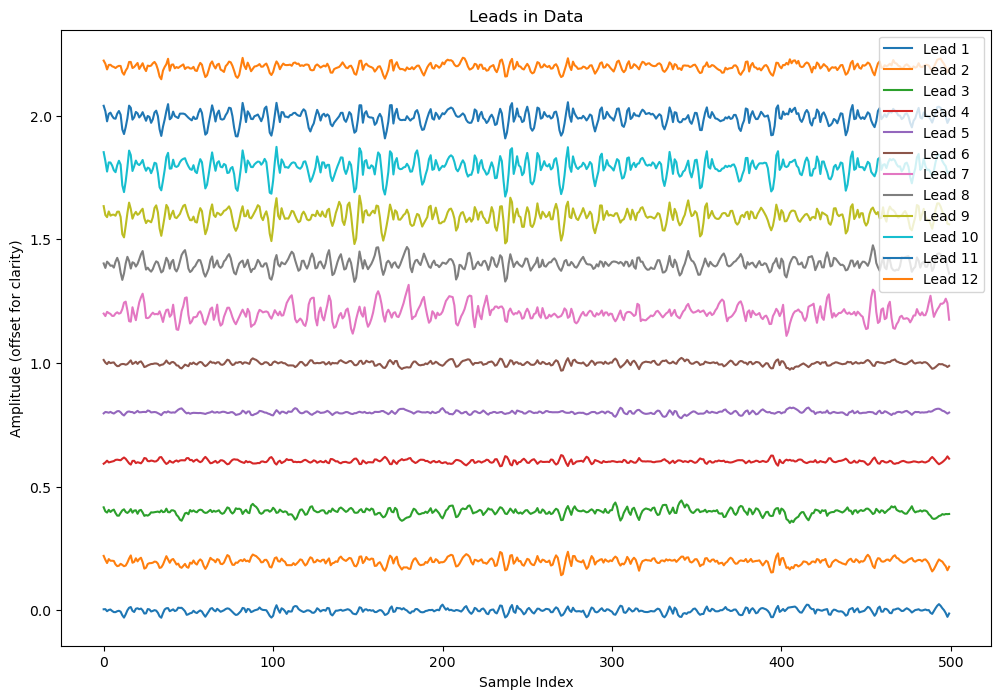

In [2]:
# plot the leads in data
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 8))
for i in range(data.shape[1]):
    plt.plot(data[:, i] + i * 0.2, label=f'Lead {i+1}')
plt.legend()
plt.title('Leads in Data')
plt.xlabel('Sample Index')
plt.ylabel('Amplitude (offset for clarity)')
plt.show()

In [3]:
# Add here the code to compute the effective rank
def effective_rank(singular_values, tol=0.98):
    """Compute the effective rank of a matrix given its singular values."""
    normalized_sv = singular_values**2 / np.sum(singular_values**2)
    cumulative_energy = np.cumsum(normalized_sv)
    rank = np.searchsorted(cumulative_energy, tol, side='right')
    return rank, tol

erank1, tol1 = effective_rank(S1)
erank2, tol2 = effective_rank(S2)

print(f'Effective Rank of Segment 1: {erank1}')
print(f'Effective Rank of Segment 2: {erank2}')

Effective Rank of Segment 1: 1
Effective Rank of Segment 2: 3


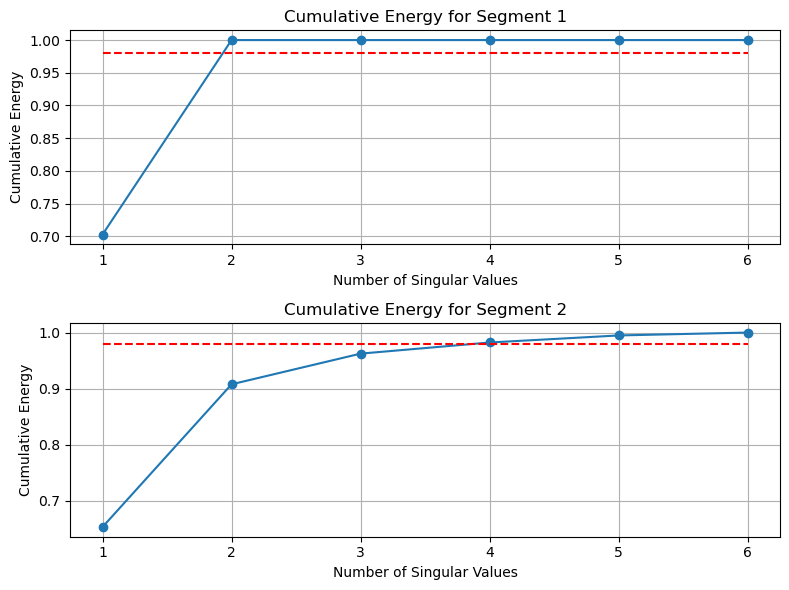

In [4]:
# plot cumulative energy
import matplotlib.pyplot as plt
def plot_cumulative_energy(singular_values, title, tol=0.98):
    normalized_sv = singular_values**2 / np.sum(singular_values**2)
    cumulative_energy = np.cumsum(normalized_sv)
    plt.plot(np.arange(1, len(singular_values)+1), cumulative_energy, marker='o')
    plt.title(title)
    plt.plot([1, len(singular_values)], [tol, tol], 'r--', label=f'Tolerance = {tol}')
    plt.xlabel('Number of Singular Values')
    plt.xticks(range(1, len(singular_values)+1))
    plt.ylabel('Cumulative Energy')
    plt.grid()


plt.figure(figsize=(8, 6))
plt.subplot(2, 1, 1)
plot_cumulative_energy(S1, 'Cumulative Energy for Segment 1')
plt.subplot(2, 1, 2)
plot_cumulative_energy(S2, 'Cumulative Energy for Segment 2')

plt.tight_layout()
plt.show()

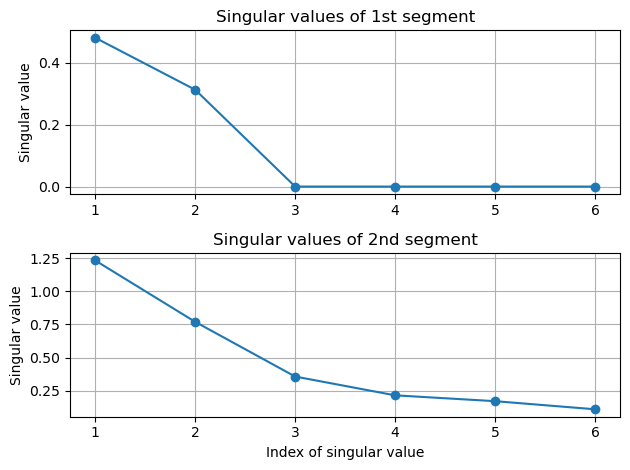

In [5]:
# plot singular values with effective rank
tol = 1e-10
import matplotlib.pyplot as plt

plt.figure()
plt.subplot(2,1,1)
plt.plot(np.arange(1, len(S1)+1), S1, 'o-')
plt.grid()
plt.title('Singular values of 1st segment')
plt.ylabel('Singular value')
plt.subplot(2,1,2)
plt.plot(np.arange(1, len(S2)+1), S2, 'o-')
plt.title('Singular values of 2nd segment')
plt.xlabel('Index of singular value')
plt.ylabel('Singular value')
plt.tight_layout()
plt.grid()
plt.show()

